# Losses and Score Functions

This notebook plots the three robust losses and their score functions using the calibrated constants from `constant_estimation.ipynb`:

- Huber: `delta = 1.3450`
- Log-cosh: `delta = 1.2047`
- Concordant: `delta = 1.4811`


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pathlib

p = pathlib.Path.cwd()
for q in (p, *p.parents):
    s = q / "src" / "ftbp"
    if s.exists():
        sys.path.insert(0, str(s.parent))
        break
else:
    raise RuntimeError("src/ftbp not found")


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ftbp.estimators import psi

sns.set_context("talk")
sns.set_style("whitegrid", {'grid.color': '#F2F2F2'})

DELTAS = {
    "huber": 1.3450,
    "logcosh": 1.2047,
    "concordant": 1.4811,
}

palette = sns.color_palette("husl", 3)
COLORS = {
    "huber": palette[0],
    "logcosh": palette[1],
    "concordant": palette[2],
}


In [3]:
def score_curve(r, delta, loss_type):
    values = psi(r, delta=delta, loss_type=loss_type)
    # The concordant closed form is undefined exactly at zero, but its limit is zero.
    return np.nan_to_num(values, nan=0.0)


def loss_curve(r, delta, loss_type):
    score = score_curve(r, delta=delta, loss_type=loss_type)
    dr = np.diff(r)
    increments = 0.5 * (score[1:] + score[:-1]) * dr
    rho = np.concatenate(([0.0], np.cumsum(increments)))
    zero_idx = np.argmin(np.abs(r))
    return rho - rho[zero_idx]


In [ ]:
sns.set_style("whitegrid")    # e.g. “darkgrid”, “ticks”, “white”
sns.set_context("talk")       # options: “paper”, “notebook”, “talk”, “poster”
palette = sns.color_palette("husl", 3)
sns.set_style("whitegrid", {'grid.color': '#F2F2F2'})
r = np.linspace(-6.0, 6.0, 1201)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, constrained_layout=True)

for loss_type, delta in DELTAS.items():
    score = score_curve(r, delta=delta, loss_type=loss_type)
    rho = loss_curve(r, delta=delta, loss_type=loss_type)
    label = f"{loss_type}"

    # different linestyles for the loss curves to make them more distinguishable when printed in black and white
    axes[0].plot(r, rho, lw=3, color=COLORS[loss_type], label=label, alpha=0.8, linestyle="-." if loss_type == "logcosh" else "--" if loss_type == "huber" else ":")
    axes[1].plot(r, score, lw=3, color=COLORS[loss_type], label=label, alpha=0.8, linestyle="-." if loss_type == "logcosh" else "--" if loss_type == "huber" else ":")

axes[0].set_title("Loss $\\rho(t)$")
axes[1].set_title("Score $\\psi(t)$")

for ax in axes:
    ax.axhline(0.0, color="0.65", lw=1)
    ax.axvline(0.0, color="0.65", lw=1)
    ax.grid(True, alpha=0.35)
    ax.set_xlabel("$t$")

axes[0].set_ylabel("Value")
# axes[1].legend(frameon=False, loc="upper left")
# change legend name to be uppercase

handles, labels = ax.get_legend_handles_labels()
for label in labels:
    if label == "huber":
        labels[labels.index(label)] = "Huber"
    elif label == "logcosh":
        labels[labels.index(label)] = "Logcosh"
    elif label == "concordant":
        labels[labels.index(label)] = "Self-concordant"
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncols=3, frameon=False)
# plt.tight_layout()

# plt.show()
plt.savefig('losses.pdf', bbox_inches='tight')

/Users/blomkvist/Desktop/PhD/Research/Finite Threshold BP(Cleaned)/src/ftbp/estimators.py:13: RuntimeWarning: invalid value encountered in divide
  return (np.sqrt(4 * (r / delta) ** 2 + 1) - 1) / (2 * (r / delta)) * delta


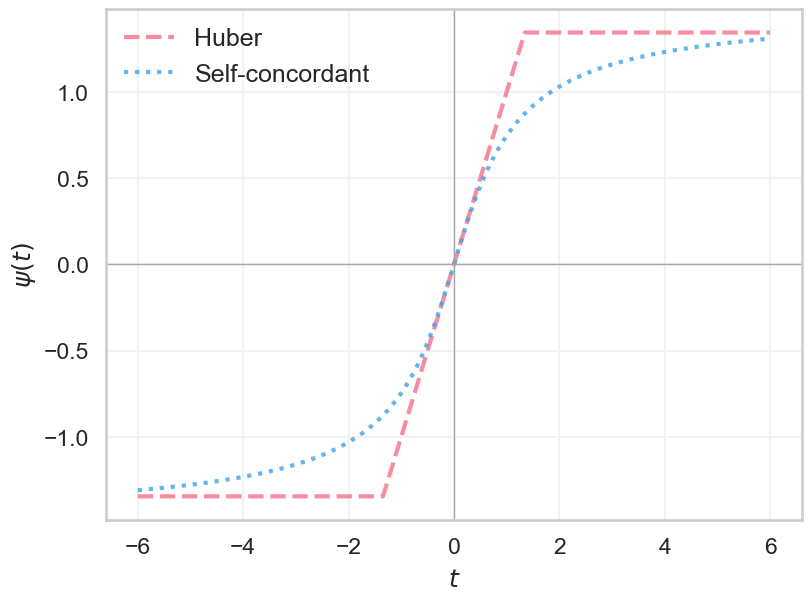

In [62]:
DELTAS = {
    "huber": 1.3450,
    "concordant": 1.4811,
}

sns.set_style("whitegrid")    # e.g. “darkgrid”, “ticks”, “white”
sns.set_context("talk")       # options: “paper”, “notebook”, “talk”, “poster”
palette = sns.color_palette("husl", 3)
sns.set_style("whitegrid", {'grid.color': '#F2F2F2'})
r = np.linspace(-6.0, 6.0, 1201)

# fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, constrained_layout=True)

# for loss_type, delta in DELTAS.items():
    # score = score_curve(r, delta=delta, loss_type=loss_type)
    # rho = loss_curve(r, delta=delta, loss_type=loss_type)
    # label = f"{loss_type}"

#     # different linestyles for the loss curves to make them more distinguishable when printed in black and white
#     axes[0].plot(r, rho, lw=3, color=COLORS[loss_type], label=label, alpha=0.8, linestyle="-." if loss_type == "logcosh" else "--" if loss_type == "huber" else ":")
#     axes[1].plot(r, score, lw=3, color=COLORS[loss_type], label=label, alpha=0.8, linestyle="-." if loss_type == "logcosh" else "--" if loss_type == "huber" else ":")

# axes[0].set_title("Loss $\\rho(t)$")

fig = plt.figure(figsize=(8, 5.9), constrained_layout=True)
for loss_type, delta in DELTAS.items():
    score = score_curve(r, delta=delta, loss_type=loss_type)
    rho = loss_curve(r, delta=delta, loss_type=loss_type)
    label = f"{loss_type}"
    plt.plot(r, score, lw=3, color=COLORS[loss_type], label=label, alpha=0.8, linestyle="-." if loss_type == "logcosh" else "--" if loss_type == "huber" else ":")

plt.axhline(0.0, color="0.65", lw=1)
plt.axvline(0.0, color="0.65", lw=1)
# plt.grid(True, alpha=0.35)

# for ax in axes:
#     ax.axhline(0.0, color="0.65", lw=1)
#     ax.axvline(0.0, color="0.65", lw=1)
#     ax.grid(True, alpha=0.35)
#     ax.set_xlabel("$t$")

# fig.set_ylabel("Value")
# axes[1].legend(frameon=False, loc="upper left")
# change legend name to be uppercase

# handles, labels = plt.get_legend_handles_labels()
# for label in labels:
#     if label == "huber":
#         labels[labels.index(label)] = "Huber"
#     elif label == "logcosh":
#         labels[labels.index(label)] = "Logcosh"
#     elif label == "concordant":
#         labels[labels.index(label)] = "Self-concordant"
# large text size for legend?
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.12, 1), ncols=1, frameon=False, fontsize=18)

plt.ylabel("$\\psi(t)$")
plt.xlabel("$t$", labelpad=8)
# plt.tight_layout()

# plt.show()
plt.savefig('losses_poster.pdf', bbox_inches='tight')